Winsorization(capping method) replaces the extreme less or high values with using choosen threshold value

uses:reducing the effect of outliers
keeping all data points
making analysis more reliable

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data=pd.read_csv("/content/drive/MyDrive/preprocessing_dataset.csv")
data

,Name,Age,Gender,Salary,Department
0,Alice,25.0,F,50000.0,HR
1,Bob,30.0,M,60000.0,Finance
2,Charlie,NaN,M,55000.0,IT
3,David,40.0,M,58000.0,HR
4,Eve,22.0,F,52000.0,IT
5,Frank,35.0,NaN,61000.0,Finance
6,Grace,120.0,F,NaN,Finance
7,Henry,28.0,M,59000.0,HR
8,Ivy,29.0,F,63000.0,IT
9,Jack,27.0,M,62000.0,Finance


In [ ]:
data['Salary']

,Salary
0,50000.0
1,60000.0
2,55000.0
3,58000.0
4,52000.0
5,61000.0
6,NaN
7,59000.0
8,63000.0
9,62000.0


In [ ]:
from scipy.stats.mstats import winsorize
win=winsorize(data['Age'],limits=[0,0.2])
print(win)

[25. 30. 40. 40. 22. 35. 40. 28. 29. 27.]


/tmp/ipykernel_559/628570824.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(a)


<Axes: xlabel='Age', ylabel='Density'>

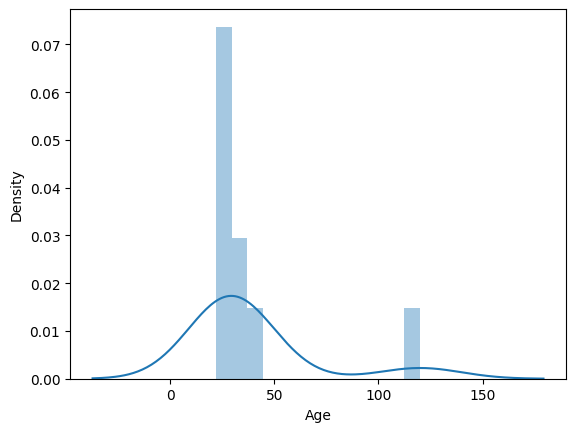

In [ ]:
a=data['Age']
sns.distplot(a)

Log transform used to replace each data with its logarithm value to reduce the effect of small/large values and also helps to balanace the skewed data

ex data=[10,100,1000] will change using formula log to the base 10 of 10(log10(10))

uses-It is useful when data is:

highly skewed
has very large outliers
grows exponentially

using pandas for dataframe

In [ ]:
data['Age'].fillna(data['Age'].mean(),inplace=True)
data['Salary'].fillna(data['Salary'].mean(),inplace=True)
data['Gender'].fillna(data['Gender'].mode()[0],inplace=True)


/tmp/ipykernel_4915/1839909438.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].mean(),inplace=True)
/tmp/ipykernel_4915/1839909438.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

In [ ]:
data['log_salary'] = np.log(data['Salary'])
print(data['log_salary'])

0    10.819778
1    11.002100
2    10.915088
3    10.968198
4    10.858999
5    11.018629
6          NaN
7    10.985293
8    11.050890
9    11.034890
Name: log_salary, dtype: float64


/tmp/ipykernel_559/628570824.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(a)


<Axes: xlabel='Age', ylabel='Density'>

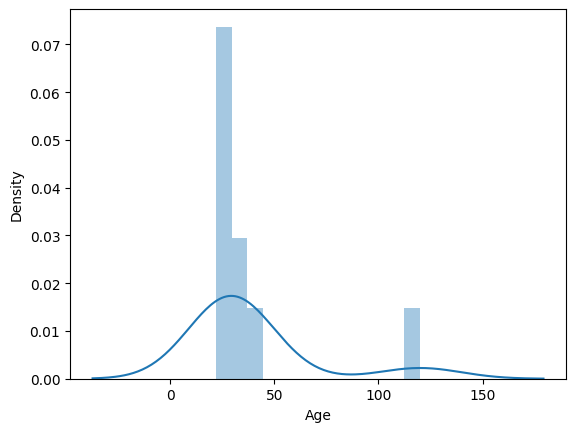

In [ ]:
a=data['Age']
sns.distplot(a)

using function transformer-A log transform is one specific type of transformation, while FunctionTransformer is a general tool used to apply any transformation function.

In [ ]:
from sklearn.preprocessing import FunctionTransformer
import numpy as np

transformer = FunctionTransformer(np.log)

log_data = transformer.transform(data['Salary'])
log_data

,Salary
0,10.819778
1,11.002100
2,10.915088
3,10.968198
4,10.858999
5,11.018629
6,NaN
7,10.985293
8,11.050890
9,11.034890


/tmp/ipykernel_559/628570824.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(a)


<Axes: xlabel='Age', ylabel='Density'>

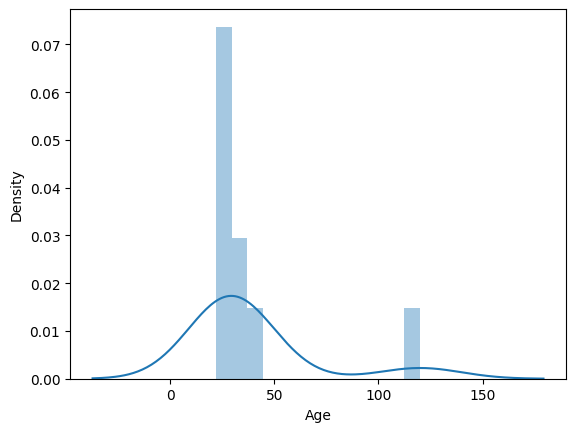

In [ ]:
a=data['Age']
sns.distplot(a)

Power transformer

a Power Transformer is a technique used to make data more normal (Gaussian-like) and reduce skewness.

1. Box-Cox Transformation

Works only for positive numbers.

2. Yeo-Johnson Transformation

Works for:

positive numbers
zero
negative numbers

formula:y=x^lambda,lambda=1(no transform),0(log transform)

In [ ]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer()
transformed = pt.fit_transform(data[['Age']])
print(transformed)

[[-0.96651361]
 [-0.10037812]
 [ 0.78487679]
 [ 0.81238868]
 [-1.75852146]
 [ 0.44535228]
 [ 1.98790862]
 [-0.39639836]
 [-0.24140006]
 [-0.56731477]]


/tmp/ipykernel_4915/2639090348.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(a)


<Axes: xlabel='Age', ylabel='Density'>

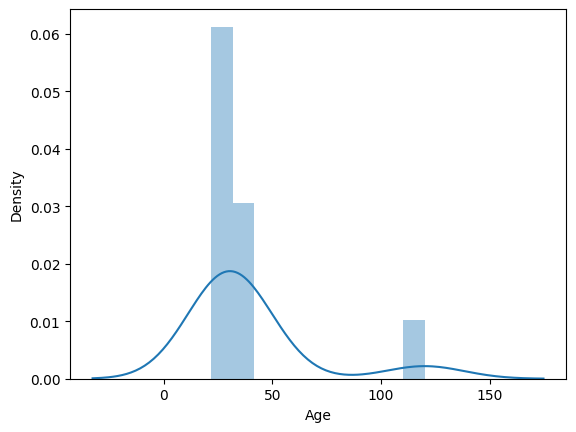

In [ ]:
a=data['Age']
sns.distplot(a)

Standard scalar

A Standard Scaler is a preprocessing technique used to standardize data so that features have:

mean = 0
standard deviation = 1

scales data near to zero centered

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(data[['Age']])

print(scaled_data)

[[-0.50401021]
 [-0.33087693]
 [        nan]
 [ 0.01538962]
 [-0.60789017]
 [-0.15774365]
 [ 2.78552206]
 [-0.40013024]
 [-0.36550359]
 [-0.4347569 ]]


/tmp/ipykernel_559/2639090348.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(a)


<Axes: xlabel='Age', ylabel='Density'>

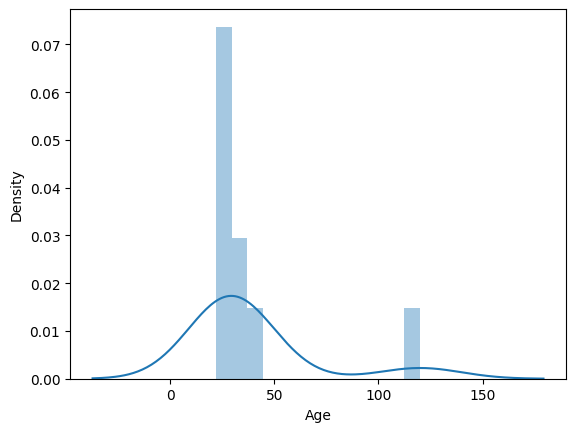

In [ ]:
a=data['Age']
sns.distplot(a)

Minmax scalar

A MinMax Scaler is a preprocessing technique that rescales data into a fixed range 0 to 1

does not close data to zero centered

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data[['Age']])
print(scaled_data)

[[0.03061224]
 [0.08163265]
 [       nan]
 [0.18367347]
 [0.        ]
 [0.13265306]
 [1.        ]
 [0.06122449]
 [0.07142857]
 [0.05102041]]


/tmp/ipykernel_559/628570824.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(a)


<Axes: xlabel='Age', ylabel='Density'>

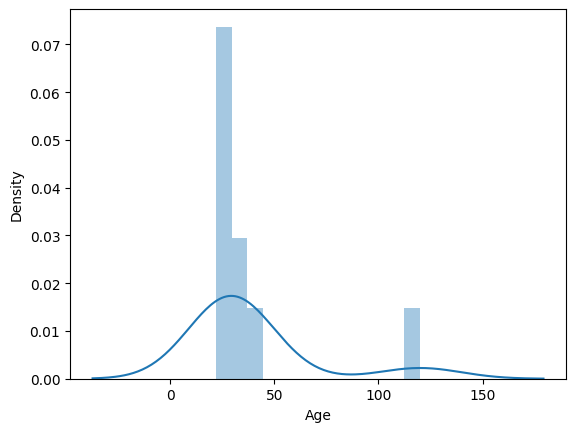

In [ ]:
a=data['Age']
sns.distplot(a)

box cox transformation

The Box-Cox method is a transformation technique used to make data more normal (less skewed).

It is a type of power transformation.

Box-Cox works only for:

positive values (> 0)

In [ ]:
from scipy.stats import boxcox
transformed_data, lambda_value = boxcox(data['Age'])
print(transformed_data)
print(lambda_value)

[0.56338301 0.56390746 0.56444049 0.56445703 0.56290029 0.56423632
 0.56516672 0.56372859 0.56382229 0.56362515]
-1.7690180978733812


/tmp/ipykernel_559/628570824.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(a)


<Axes: xlabel='Age', ylabel='Density'>

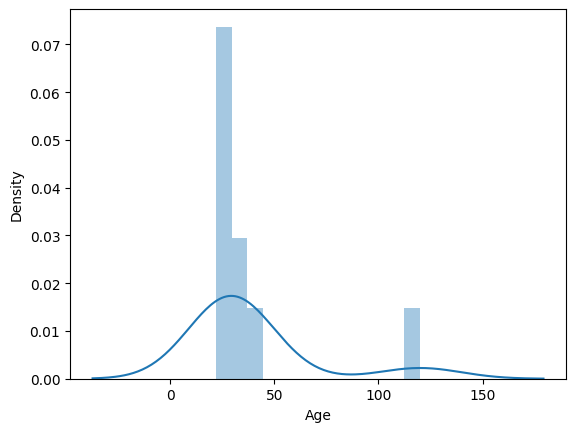

In [ ]:
a=data['Age']
sns.distplot(a)